# Impact métier du modèle de prévision

Ce carnet mesure ce que le modèle **fait gagner à l'exploitant**, et non sa précision statistique.
La précision est traitée dans `model_selection.ipynb` ; ici on cherche autre chose : si les
prévisions alimentaient les recommandations, qu'est-ce que l'exploitant y gagnerait.

**Deux indicateurs, et aucune hypothèse.** Combien de dépassements le modèle annonce, et combien de
temps d'avance il donne. Les deux se mesurent directement sur les prévisions rejouées : rien ici ne
suppose qu'une recommandation ait été suivie, ni qu'elle ait produit un effet.

**Périmètre.** Les sept sites du parc, sur le bloc de test que l'entraînement exclut.

**Lien avec les tickets.** La boucle de recommandation n'existe pas encore : #43, #44 et #45 sont
ouverts, et la règle appartient à l'applicatif, pas au service ML (`docs/api.md`, section 6). La
règle appliquée ici la simule, à partir des paramètres déjà tranchés : seuil de vigilance à 80 % de
la capacité souscrite par défaut (`docs/data.md`), horizon de 1 à 48 heures (`docs/api.md`). Ce
carnet ne crée aucun module ; il fige par la mesure le seuil de déclenchement que #44 devra
implémenter.

## 1. Données, modèle et bornes de l'étude

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from data import read_training_history
from features import MINIMUM_HISTORY_HOURS, load_site_schedules
from models import PredictionService, PredictionTarget, load_model
from training import VALIDATION_QUANTILE


def repository_root():
    """Remonte jusqu'au dossier qui porte `.git`, pour ne dépendre ni du répertoire de travail
    du noyau ni de la profondeur du carnet dans l'arborescence."""
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Racine du dépôt introuvable depuis " + str(Path.cwd()))


REPOSITORY_ROOT = repository_root()

# Mêmes variables d'environnement que le service, mêmes défauts. Le carnet suit donc un
# PARQUET_DIR déplacé sans qu'on ait à l'éditer.
PARQUET_DIRECTORY = Path(os.getenv("PARQUET_DIR") or REPOSITORY_ROOT / "data" / "parquet")
SITES_FILE = PARQUET_DIRECTORY / "sites.parquet"
MODEL_FILE = Path(
    os.getenv("ML_MODEL_PATH") or REPOSITORY_ROOT / "apps" / "ml" / "artifacts" / "catboost_model.cbm"
)
SCHEDULES_FILE = Path(
    os.getenv("ML_SITE_CONFIG_PATH") or REPOSITORY_ROOT / "apps" / "ml" / "config" / "sites.json"
)

FORECAST_HORIZON_HOURS = 24      # horizon par défaut du contrat d'API
ORIGIN_STEP_HOURS = 6            # un exploitant ne relit pas sa prévision toutes les heures
DEFAULT_THRESHOLD_RATIO = 0.80   # seuil de vigilance par défaut, docs/data.md
USEFUL_LEAD_HOURS = (6, 12, 18)  # paliers de préavis rapportés par le KPI 2

In [2]:
history = read_training_history(PARQUET_DIRECTORY)
sites = pq.read_table(SITES_FILE).to_pandas().set_index("id")
schedules = load_site_schedules(SCHEDULES_FILE)
model = load_model(MODEL_FILE)

# Le modèle a été entraîné sur les heures les plus anciennes de cette fenêtre. La coupe vient de
# `training`, et non d'un second littéral : une valeur recopiée dériverait sans rien casser, et
# l'étude se mettrait à mesurer le modèle sur des heures qu'il a déjà vues.
TRAINING_CUTOFF = history["timestamp"].quantile(VALIDATION_QUANTILE)
test_block = history[history["timestamp"] > TRAINING_CUTOFF]
TEST_WEEKS = (test_block.timestamp.max() - test_block.timestamp.min()) / pd.Timedelta(weeks=1)

print(f"historique lu         : {len(history):,} lignes, {history.site_id.nunique()} sites")
print(f"fin de l'entrainement : {TRAINING_CUTOFF}")
print(f"bloc de test          : {test_block.timestamp.min()} -> {test_block.timestamp.max()}")
print(f"                        {len(test_block):,} heures, soit {TEST_WEEKS:.1f} semaines")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

historique lu         : 122,647 lignes, 7 sites
fin de l'entrainement : 2026-05-31 23:00:00
bloc de test          : 2026-06-01 00:00:00 -> 2026-09-18 11:00:00
                        18,396 heures, soit 15.6 semaines


In [3]:
# Le seuil de vigilance par défaut, celui que l'applicatif applique tant qu'aucun réglage manuel
# n'est saisi. warning_threshold_kw vit en base et n'est pas dans le Parquet : la simulation ne
# connaît donc que le défaut, et c'est une limite à garder en tête.
SITE_IDS = sorted(history.site_id.unique())
thresholds = {
    site_id: DEFAULT_THRESHOLD_RATIO * float(sites.loc[site_id, "capacity_kw"])
    for site_id in SITE_IDS
}

summary = []
for site_id, block in test_block.groupby("site_id"):
    above = int((block.consumption_kwh_corrected > thresholds[site_id]).sum())
    summary.append({
        "site": site_id,
        "type": sites.loc[site_id, "type"],
        "capacite_kw": sites.loc[site_id, "capacity_kw"],
        "seuil_kw": thresholds[site_id],
        "moyenne_kwh": block.consumption_kwh_corrected.mean(),
        "heures_au_dessus": above,
        "part_%": 100 * above / len(block),
    })
pd.DataFrame(summary).round(1)

,site,type,capacite_kw,seuil_kw,moyenne_kwh,heures_au_dessus,part_%
0,SITE001,office,200.0,160.0,91.6,282,10.7
1,SITE002,factory,1000.0,800.0,538.7,827,31.5
2,SITE003,datacenter,800.0,640.0,717.3,2559,97.4
3,SITE004,retail,400.0,320.0,224.2,307,11.7
4,SITE005,hospital,600.0,480.0,461.6,647,24.6
5,SITE006,office,180.0,144.0,80.3,141,5.4
6,SITE007,factory,950.0,760.0,501.7,787,29.9


Première lecture, et elle pèse sur toute la suite : **les sites à charge plate passent la
quasi-totalité de leurs heures au-dessus de leur seuil de vigilance par défaut**, leur charge de base
approchant leur capacité souscrite. Une règle calée sur ce défaut y déclencherait en permanence, ce
qui n'est pas une alerte mais un bruit de fond. On garde le défaut pour la mesure de référence, et la
section 5 en fait le premier ajustement.

## 2. Rejouer la prévision sur le bloc de test

Toutes les six heures, on demande au modèle les vingt-quatre heures suivantes, en ne lui donnant que
l'historique réellement connu à cet instant. La prévision est autorégressive : chaque heure prédite
devient le décalage de la suivante, exactement comme en production.

In [4]:
def backtest(site_id, horizon=FORECAST_HORIZON_HOURS, step=ORIGIN_STEP_HOURS):
    """Rejoue la prévision toutes les `step` heures sur le bloc de test d'un site."""
    # `read_training_history` rend déjà les lignes triées par site puis par horodatage.
    site_history = history[history.site_id == site_id]
    first_origin = site_history[site_history.timestamp > TRAINING_CUTOFF].timestamp.min()
    last_origin = site_history.timestamp.max() - pd.Timedelta(hours=horizon)
    origins = pd.date_range(start=first_origin, end=last_origin, freq=f"{step}h")

    rows = []
    for origin in origins:
        known = site_history[site_history.timestamp <= origin].tail(MINIMUM_HISTORY_HOURS)
        service = PredictionService(model, known, schedules)
        targets = [
            PredictionTarget(site_id, (origin + pd.Timedelta(hours=k)).to_pydatetime())
            for k in range(1, horizon + 1)
        ]
        for prediction in service.predict(targets):
            due_at = pd.Timestamp(prediction.timestamp)
            rows.append({
                "site_id": site_id,
                "origin": origin,
                "due_at": due_at,
                "lead_hours": int((due_at - origin).total_seconds() // 3600),
                "forecast_kwh": prediction.consumption_kwh,
            })
    return pd.DataFrame(rows)


forecasts = pd.concat([backtest(site_id) for site_id in SITE_IDS], ignore_index=True)

observed = history[["site_id", "timestamp", "consumption_kwh_corrected"]].rename(
    columns={"timestamp": "due_at", "consumption_kwh_corrected": "observed_kwh"}
)
forecasts = forecasts.merge(observed, on=["site_id", "due_at"], how="left")
forecasts["absolute_error"] = (forecasts.forecast_kwh - forecasts.observed_kwh).abs()

print(f"{len(forecasts):,} previsions, {forecasts.origin.nunique():,} origines")
forecasts.head()

72,912 previsions, 434 origines


,site_id,origin,due_at,lead_hours,forecast_kwh,observed_kwh,absolute_error
0,SITE001,2026-06-01,2026-06-01 01:00:00,1,59.259826,61.23,1.970174
1,SITE001,2026-06-01,2026-06-01 02:00:00,2,60.127582,59.97,0.157582
2,SITE001,2026-06-01,2026-06-01 03:00:00,3,61.447781,65.98,4.532219
3,SITE001,2026-06-01,2026-06-01 04:00:00,4,59.922608,59.90,0.022608
4,SITE001,2026-06-01,2026-06-01 05:00:00,5,61.144394,59.10,2.044394


### Dégradation par horizon

Résultat intermédiaire, absent du carnet de sélection : celui-ci mesurait l'erreur sur une fenêtre
unique de 168 heures. Ici on dispose de centaines de fenêtres, donc de l'erreur **en fonction de la
distance à l'origine**. C'est la grandeur qui décide si une recommandation à vingt-quatre heures a un
sens.

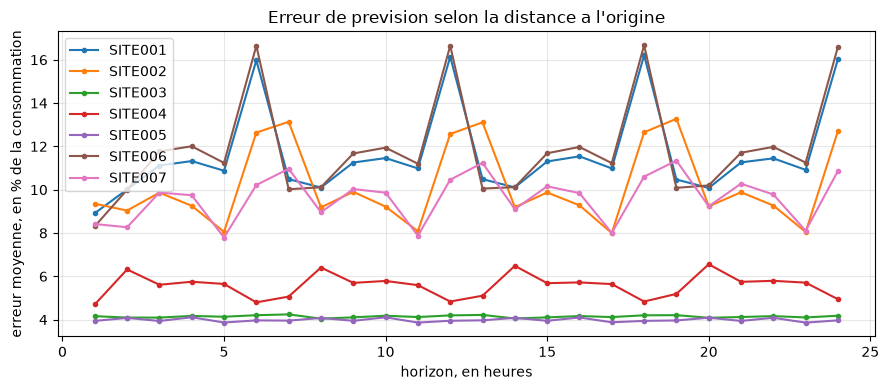

site_id,SITE001,SITE002,SITE003,SITE004,SITE005,SITE006,SITE007
lead_hours,,,,,,,
1,8.9,9.4,4.2,4.7,3.9,8.3,8.4
6,16.0,12.6,4.2,4.8,4.0,16.6,10.2
12,16.1,12.6,4.2,4.8,3.9,16.6,10.5
24,16.0,12.7,4.2,4.9,4.0,16.6,10.9


In [5]:
by_horizon = (
    forecasts.groupby(["site_id", "lead_hours"])
    .agg(mae=("absolute_error", "mean"), observed_mean=("observed_kwh", "mean"))
    .reset_index()
)
by_horizon["mae_relative_%"] = 100 * by_horizon.mae / by_horizon.observed_mean

_, axes = plt.subplots(figsize=(9, 4))
for site_id, group in by_horizon.groupby("site_id"):
    axes.plot(group.lead_hours, group["mae_relative_%"], marker="o", markersize=3, label=site_id)
axes.set_xlabel("horizon, en heures")
axes.set_ylabel("erreur moyenne, en % de la consommation")
axes.set_title("Erreur de prevision selon la distance a l'origine")
axes.legend()
axes.grid(alpha=0.3)
plt.tight_layout()
plt.show()

horizon_marks = [1, FORECAST_HORIZON_HOURS // 4, FORECAST_HORIZON_HOURS // 2, FORECAST_HORIZON_HOURS]
by_horizon[by_horizon.lead_hours.isin(horizon_marks)].pivot(
    index="lead_hours", columns="site_id", values="mae_relative_%"
).round(1)

## 3. La règle de recommandation

Une heure future dont la prévision franchit le seuil de vigilance produit une recommandation. Une
même heure étant vue par plusieurs origines successives, on garde le **préavis le plus long** : c'est
le moment où l'exploitant a été averti pour la première fois.

La comparaison est faite avec la règle de seuil sans modèle (#43), qui ne voit le dépassement qu'une
fois la mesure tombée. Elle n'a donc **rien à annoncer et aucun préavis à offrir**, par construction :
c'est le zéro contre lequel les deux indicateurs se lisent.

In [6]:
def recommendations(site_forecasts, threshold, trigger=1.00):
    """Les heures futures signalees, avec le preavis le plus long obtenu pour chacune.

    `trigger` module le seuil de declenchement : a 0,95 on alerte des 95 % du seuil de vigilance,
    pour rattraper ce que le modele sous-estime. C'est le levier ajuste en section 6.
    """
    flagged = site_forecasts[site_forecasts.forecast_kwh > trigger * threshold]
    return (
        flagged.sort_values("lead_hours", ascending=False)
        .drop_duplicates("due_at")
        .sort_values("due_at")[["due_at", "lead_hours"]]
        .reset_index(drop=True)
    )


def observed_series(site_id):
    """La consommation reelle des heures couvertes par le backtest de ce site."""
    covered = forecasts.loc[forecasts.site_id == site_id, "due_at"]
    return (
        history[(history.site_id == site_id) & (history.timestamp.isin(covered))]
        .set_index("timestamp")
        .consumption_kwh_corrected.sort_index()
    )

## 4. Les deux indicateurs

**Pics anticipés.** Sur les dépassements qui ont réellement eu lieu, la part que le modèle avait
annoncée, accompagnée du taux de fausses alertes. Le second est obligatoire : sans lui, le premier se
maximise en criant au loup en permanence. On rapporte aussi le nombre d'alertes par semaine, qui est
la charge que la règle fait peser sur l'exploitant.

**Temps d'action gagné.** Sur les dépassements annoncés, le préavis obtenu, et la part de ceux
annoncés avec au moins 6, 12 et 18 heures de marge. La médiane seule cacherait qu'un préavis de deux
heures et un de vingt-deux heures n'ont pas la même valeur.

Aucun des deux ne suppose qu'une recommandation ait été suivie.

In [7]:
def evaluate(site_id, threshold, trigger=1.00):
    """Les deux indicateurs pour un site, un seuil et un coefficient de declenchement."""
    series = observed_series(site_id)
    alerts = recommendations(forecasts[forecasts.site_id == site_id], threshold, trigger)

    real_peaks = set(series.index[series > threshold])
    announced = set(alerts.due_at)
    caught = real_peaks & announced
    leads = alerts.loc[alerts.due_at.isin(caught), "lead_hours"]

    return {
        "site": site_id,
        "depassements": len(real_peaks),
        "annonces_%": 100 * len(caught) / len(real_peaks) if real_peaks else np.nan,
        "fausses_alertes_%": 100 * len(announced - real_peaks) / len(announced) if announced else np.nan,
        "alertes_par_semaine": len(alerts) / TEST_WEEKS,
        "preavis_median_h": leads.median() if not leads.empty else np.nan,
        **{
            f"preavis_{hours}h+_%": 100 * (leads >= hours).mean() if not leads.empty else np.nan
            for hours in USEFUL_LEAD_HOURS
        },
    }


def evaluate_all(threshold_by_site, trigger=1.00):
    return pd.DataFrame(
        evaluate(site_id, threshold_by_site[site_id], trigger) for site_id in SITE_IDS
    )


results = evaluate_all(thresholds)
results.round(1)

,site,depassements,annonces_%,fausses_alertes_%,alertes_par_semaine,preavis_median_h,preavis_6h+_%,preavis_12h+_%,preavis_18h+_%
0,SITE001,281,63.7,40.7,19.3,22.0,99.4,98.9,96.6
1,SITE002,823,93.2,17.9,59.7,21.0,99.7,99.1,97.5
2,SITE003,2553,100.0,2.6,167.7,21.0,99.8,99.6,99.4
3,SITE004,306,69.6,44.8,24.7,21.0,97.2,96.2,93.9
4,SITE005,641,46.2,46.7,35.5,21.0,99.0,97.0,94.9
5,SITE006,139,17.3,40.0,2.6,22.0,95.8,95.8,95.8
6,SITE007,783,88.3,17.2,53.4,21.0,99.4,98.1,97.0


Le modèle annonce bien ce qui arrive souvent et rate ce qui arrive rarement : le rappel suit la
fréquence des dépassements, d'un bureau qui dépasse une heure sur vingt à un datacenter qui dépasse
en permanence. Le préavis, lui, est confortable partout, et c'est le gain net sur la règle de seuil
seule, qui n'en offre aucun.

## 5. Premier ajustement : le seuil des sites saturés

**Ce qui est changé.** Le déclencheur passe de 80 % de la capacité souscrite au 90e percentile de
l'historique d'entraînement du site, pour les seuls sites dont le défaut est dépassé plus d'une heure
sur deux.

**Pourquoi.** Un site dont la charge de base vaut 90 % de sa capacité est en alerte permanente, et
une alerte permanente n'est pas une alerte.

**Ce que cela coûte.** Le seuil ajusté décrit le comportement du site et non plus son contrat
d'abonnement : il ne dit donc plus rien du risque de pénalité. Les deux lectures sont
complémentaires, pas interchangeables.

In [8]:
SATURATION_LIMIT_PERCENT = 50.0   # au-dela, le seuil decrit le regime normal du site
ADJUSTED_PERCENTILE = 0.90        # le site est signale sur ses propres heures hautes

training_block = history[history.timestamp <= TRAINING_CUTOFF]
adjusted = {}
adjustment_rows = []
for site_id, block in training_block.groupby("site_id"):
    consumption = block.consumption_kwh_corrected
    saturation = 100 * (consumption > thresholds[site_id]).mean()
    is_saturated = saturation > SATURATION_LIMIT_PERCENT
    adjusted[site_id] = (
        float(consumption.quantile(ADJUSTED_PERCENTILE)) if is_saturated else thresholds[site_id]
    )
    adjustment_rows.append({
        "site": site_id,
        "saturation_entrainement_%": saturation,
        "seuil_defaut_kw": thresholds[site_id],
        "seuil_ajuste_kw": adjusted[site_id],
        "ajuste": is_saturated,
    })

pd.DataFrame(adjustment_rows).round(1)

,site,saturation_entrainement_%,seuil_defaut_kw,seuil_ajuste_kw,ajuste
0,SITE001,14.9,160.0,160.0,False
1,SITE002,34.6,800.0,800.0,False
2,SITE003,98.0,640.0,779.9,True
3,SITE004,17.0,320.0,320.0,False
4,SITE005,35.7,480.0,480.0,False
5,SITE006,9.6,144.0,144.0,False
6,SITE007,33.6,760.0,760.0,False


In [9]:
adjusted_results = evaluate_all(adjusted)

comparison = results.set_index("site")[["depassements", "annonces_%", "fausses_alertes_%"]].join(
    adjusted_results.set_index("site")[["depassements", "annonces_%", "fausses_alertes_%"]],
    lsuffix="_avant",
    rsuffix="_apres",
)
comparison.round(1)

,depassements_avant,annonces_%_avant,fausses_alertes_%_avant,depassements_apres,annonces_%_apres,fausses_alertes_%_apres
site,,,,,,
SITE001,281,63.7,40.7,281,63.7,40.7
SITE002,823,93.2,17.9,823,93.2,17.9
SITE003,2553,100.0,2.6,176,0.0,NaN
SITE004,306,69.6,44.8,306,69.6,44.8
SITE005,641,46.2,46.7,641,46.2,46.7
SITE006,139,17.3,40.0,139,17.3,40.0
SITE007,783,88.3,17.2,783,88.3,17.2


**Le résultat est mauvais, et c'est l'enseignement.** Le seuil relevé supprime les fausses alertes,
mais le rappel s'effondre : sur les dépassements du nouveau seuil, le modèle n'en annonce presque
aucun. Il suit bien le régime normal d'un site, il n'annonce pas ses extrêmes rares.

## 6. Second ajustement : le coefficient de déclenchement

**Ce qui est changé.** La recommandation ne part plus quand la prévision franchit le seuil, mais
quand elle atteint une fraction de ce seuil.

**Pourquoi.** La section 5 montre que le modèle sous-estime les pointes. Déclencher plus tôt doit
donc rattraper une partie des dépassements manqués. C'est un levier que nous contrôlons, contrairement
au comportement du modèle.

**Ce que cela coûte.** Des fausses alertes, mécaniquement. L'arbitrage se lit dans la table.

In [10]:
TRIGGER_GRID = [0.85, 0.90, 0.95, 1.00]

trigger_rows = []
for trigger in TRIGGER_GRID:
    for row in evaluate_all(thresholds, trigger).to_dict("records"):
        trigger_rows.append({"declenchement": trigger, **row})

trigger_table = pd.DataFrame(trigger_rows)
trigger_table.pivot(index="declenchement", columns="site", values="annonces_%").round(1)

site,SITE001,SITE002,SITE003,SITE004,SITE005,SITE006,SITE007
declenchement,,,,,,,
0.85,100.0,99.9,100.0,100.0,100.0,100.0,100.0
0.90,100.0,99.5,100.0,99.3,99.8,100.0,99.5
0.95,94.7,99.5,100.0,94.1,89.2,87.8,99.0
1.00,63.7,93.2,100.0,69.6,46.2,17.3,88.3


In [11]:
print("Fausses alertes, en % des annonces")
display(trigger_table.pivot(index="declenchement", columns="site", values="fausses_alertes_%").round(1))

print()
print("Alertes par semaine et par site")
display(trigger_table.pivot(index="declenchement", columns="site", values="alertes_par_semaine").round(1))

Fausses alertes, en % des annonces


site,SITE001,SITE002,SITE003,SITE004,SITE005,SITE006,SITE007
declenchement,,,,,,,
0.85,60.5,28.1,2.6,77.2,75.6,80.4,30.5
0.90,59.7,25.0,2.6,69.2,75.5,78.7,26.5
0.95,54.2,22.7,2.6,58.7,66.2,70.7,25.0
1.00,40.7,17.9,2.6,44.8,46.7,40.0,17.2



Alertes par semaine et par site


site,SITE001,SITE002,SITE003,SITE004,SITE005,SITE006,SITE007
declenchement,,,,,,,
0.85,45.5,73.1,167.7,85.7,167.7,45.4,72.1
0.90,44.6,69.8,167.7,63.2,167.0,41.7,67.8
0.95,37.2,67.7,167.7,44.6,108.3,26.7,66.1
1.00,19.3,59.7,167.7,24.7,35.5,2.6,53.4


## 7. Synthèse

Les conclusions sont reprises dans `docs/ml.md`, avec les écarts, **y compris ceux qui sont
défavorables au modèle**. Ce carnet en est la pièce justificative : il se rejoue d'une commande et ses
chiffres sont reproductibles.

In [12]:
print("Bloc de test :", test_block.timestamp.min(), "->", test_block.timestamp.max())
print("Sites        :", ", ".join(SITE_IDS))
print()
print("Seuil par defaut, declenchement a 100 % :")
print(results[["site", "depassements", "annonces_%", "fausses_alertes_%", "preavis_median_h"]]
      .round(1).to_string(index=False))

Bloc de test : 2026-06-01 00:00:00 -> 2026-09-18 11:00:00
Sites        : SITE001, SITE002, SITE003, SITE004, SITE005, SITE006, SITE007

Seuil par defaut, declenchement a 100 % :
   site  depassements  annonces_%  fausses_alertes_%  preavis_median_h
SITE001           281        63.7               40.7              22.0
SITE002           823        93.2               17.9              21.0
SITE003          2553       100.0                2.6              21.0
SITE004           306        69.6               44.8              21.0
SITE005           641        46.2               46.7              21.0
SITE006           139        17.3               40.0              22.0
SITE007           783        88.3               17.2              21.0
